In [1]:
import pandas as pd
import numpy as np
from datetime import datetime


sales = pd.read_csv(r'C:\Users\Malak Eissa\Downloads\Fact_Sales.csv', low_memory=False)

basket = pd.read_csv(r'C:\Users\Malak Eissa\Downloads\basket.csv')

customers = pd.read_csv(r'C:\Users\Malak Eissa\Downloads\Dim_Customer.csv')

products = pd.read_csv(r'C:\Users\Malak Eissa\Downloads\Dim_Product.csv')

dates = pd.read_csv(r'C:\Users\Malak Eissa\Downloads\Dim_Date.csv')

print("✅ Data Loaded Successfully!")
print(f"Sales Shape: {sales.shape}")
print(f"Basket Shape: {basket.shape}")
print(f"Customers Shape: {customers.shape}")


sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'], errors='coerce')

sales['TotalPrice'] = sales['Quantity'] * sales['UnitPrice']

sales = sales[sales['Quantity'] > 0].copy()

print("✅ Preprocessing Completed!")
print(f"Cleaned Sales Shape: {sales.shape}")

✅ Data Loaded Successfully!
Sales Shape: (530104, 6)
Basket Shape: (530104, 2)
Customers Shape: (4339, 4)
✅ Preprocessing Completed!
Cleaned Sales Shape: (530104, 7)


C:\Users\Malak Eissa\AppData\Local\Temp\ipykernel_24344\3410193482.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'], errors='coerce')


Apriori

In [3]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

basket_pivot = (
    basket.groupby(['InvoiceNo', 'Description'])['Description']
    .count()
    .unstack()
    .fillna(0)
)

basket_pivot = basket_pivot.gt(0)



print(f"Transaction Matrix Shape: {basket_pivot.shape}")

frequent_itemsets = apriori(basket_pivot, 
                            min_support=0.01,  
                            use_colnames=True,
                            verbose=1)

print(f"\nNumber of Frequent Itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.head(10))

rules = association_rules(frequent_itemsets, 
                          metric="lift", 
                          min_threshold=1.5)

rules = rules[(rules['confidence'] >= 0.5) & (rules['lift'] >= 1.5)]

rules = rules.sort_values(['lift', 'confidence'], ascending=False)

print("\n=== Top 15 Strong Association Rules (Apriori) ===")
print(rules[['antecedents', 'consequents', 'support', 
             'confidence', 'lift']].head(15))

rules.to_excel(r'C:\Users\Malak Eissa\Downloads\Apr.xlsx', index=False)
print("\nApriori Results saved successfully!")

Transaction Matrix Shape: (19959, 4016)
Processing 540 combinations | Sampling itemset size 5 43

Number of Frequent Itemsets: 1902
    support                               itemsets
0  0.014229       (CREAM CUPID HEARTS COAT HANGER)
1  0.022997  (KNITTED UNION FLAG HOT WATER BOTTLE)
2  0.021494       (RED WOOLLY HOTTIE WHITE HEART.)
3  0.019039         (SET 7 BABUSHKA NESTING BOXES)
4  0.113032   (WHITE HANGING HEART T-LIGHT HOLDER)
5  0.015382                  (WHITE METAL LANTERN)
6  0.023999               (HAND WARMER UNION JACK)
7  0.072899        (ASSORTED COLOUR BIRD ORNAMENT)
8  0.010522   (BOX OF 6 ASSORTED COLOUR TEASPOONS)
9  0.013377       (BOX OF VINTAGE ALPHABET BLOCKS)

=== Top 15 Strong Association Rules (Apriori) ===
                                      antecedents  \
2963  (HERB MARKER PARSLEY, HERB MARKER ROSEMARY)   
2966                          (HERB MARKER THYME)   
2967                       (HERB MARKER ROSEMARY)   
2962     (HERB MARKER PARSLEY, HERB MARKER T

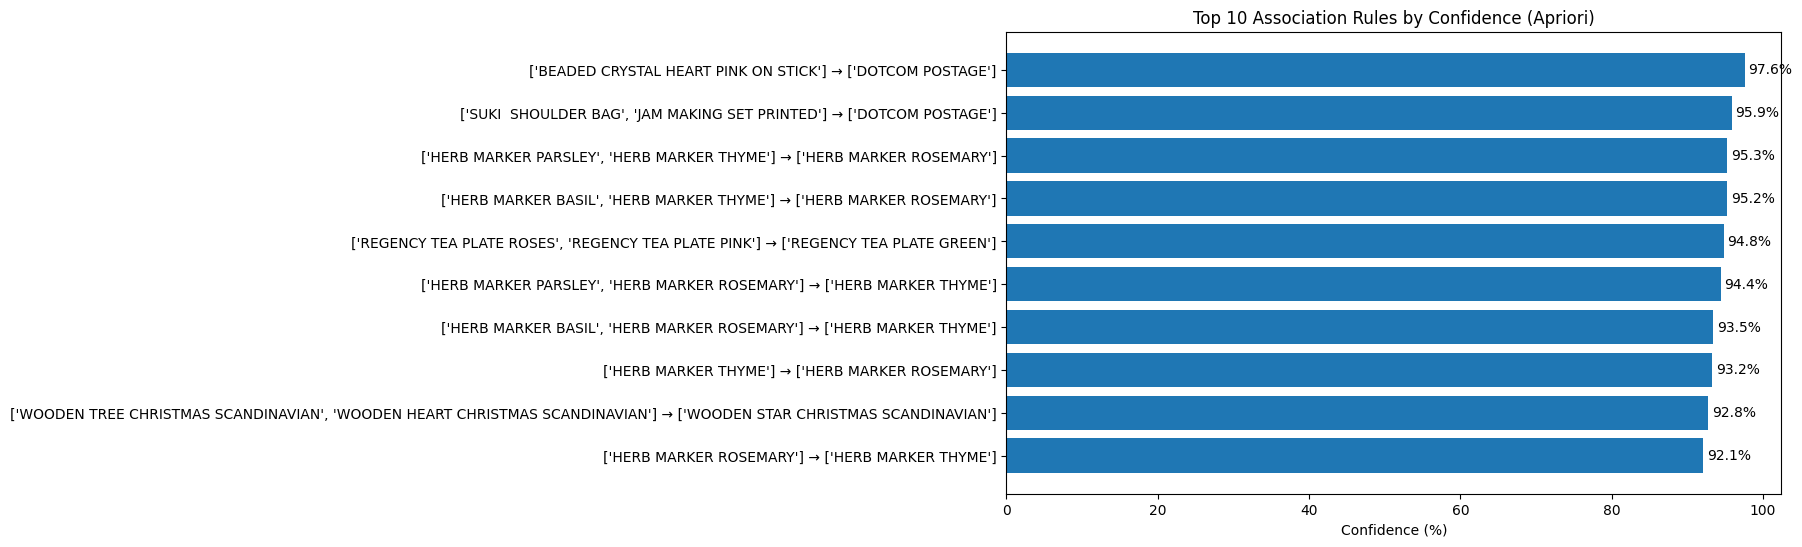

In [4]:
import matplotlib.pyplot as plt

top_rules = rules.sort_values('confidence', ascending=False).head(10)

conf_values = top_rules['confidence'] * 100

plt.figure(figsize=(10,6))
bars = plt.barh(range(len(top_rules)), conf_values)

plt.yticks(
    range(len(top_rules)),
    [f"{list(a)} → {list(c)}" for a, c in zip(top_rules['antecedents'], top_rules['consequents'])]
)

plt.xlabel("Confidence (%)")
plt.title("Top 10 Association Rules by Confidence (Apriori)")
plt.gca().invert_yaxis()

for i, v in enumerate(conf_values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.show()

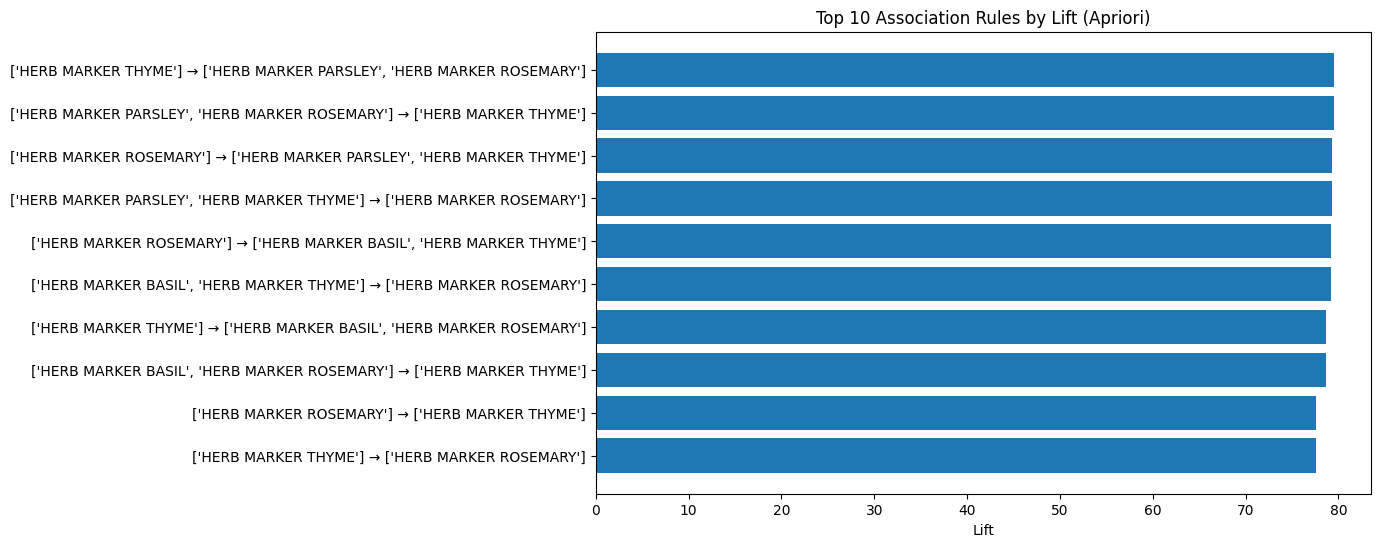

In [5]:
import matplotlib.pyplot as plt

top_rules = rules.sort_values('lift', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(range(len(top_rules)), top_rules['lift'])

plt.yticks(
    range(len(top_rules)),
    [f"{list(a)} → {list(c)}" for a, c in zip(top_rules['antecedents'], top_rules['consequents'])]
)

plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift (Apriori)")
plt.gca().invert_yaxis()

plt.show()

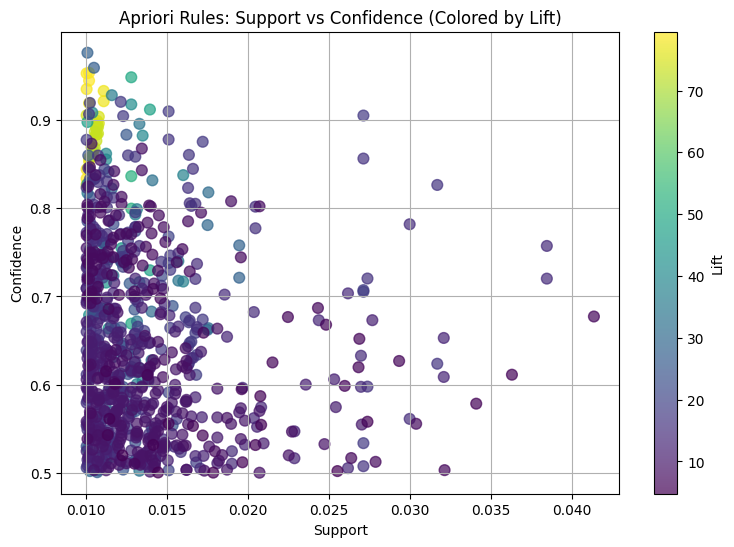

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='viridis',
    alpha=0.7,
    s=60
)

plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Apriori Rules: Support vs Confidence (Colored by Lift)')
plt.grid(True)
plt.show()

Fp_growth

In [10]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

basket_pivot_binary = basket_pivot.applymap(lambda x: 1 if x > 0 else 0)

print(f"Transaction Matrix Shape: {basket_pivot_binary.shape}")

print("Running FP-Growth Algorithm...")
frequent_itemsets_fp = fpgrowth(
    basket_pivot_binary, 
    min_support=0.01, 
    use_colnames=True
)

print(f"Number of Frequent Itemsets: {len(frequent_itemsets_fp)}")

rules_fp = association_rules(
    frequent_itemsets_fp, 
    metric="lift", 
    min_threshold=1.5
)

rules_fp = rules_fp[(rules_fp['confidence'] >= 0.5) & (rules_fp['lift'] >= 1.5)]

rules_fp = rules_fp.sort_values(by=['lift', 'confidence'], ascending=False)

print("\n=== Top 15 Strong Association Rules (FP-Growth - Unified) ===")
print(rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

output_path = r"C:/Users/Malak Eissa/Downloads/FPG_Unified_Results.xlsx"
rules_fp.to_excel(output_path, index=False)

print(f"\nResults saved successfully to:\n{output_path}")

C:\Users\Malak Eissa\AppData\Local\Temp\ipykernel_24344\2125502161.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_pivot_binary = basket_pivot.applymap(lambda x: 1 if x > 0 else 0)


Transaction Matrix Shape: (19959, 4016)
Running FP-Growth Algorithm...


C:\Users\Malak Eissa\AppData\Local\Programs\Python\Python310\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Number of Frequent Itemsets: 1902

=== Top 15 Strong Association Rules (FP-Growth - Unified) ===
                                      antecedents  \
1555  (HERB MARKER PARSLEY, HERB MARKER ROSEMARY)   
1558                          (HERB MARKER THYME)   
1559                       (HERB MARKER ROSEMARY)   
1554     (HERB MARKER PARSLEY, HERB MARKER THYME)   
1560       (HERB MARKER BASIL, HERB MARKER THYME)   
1565                       (HERB MARKER ROSEMARY)   
1561    (HERB MARKER BASIL, HERB MARKER ROSEMARY)   
1564                          (HERB MARKER THYME)   
1546                          (HERB MARKER THYME)   
1547                       (HERB MARKER ROSEMARY)   
1556    (HERB MARKER THYME, HERB MARKER ROSEMARY)   
1557                        (HERB MARKER PARSLEY)   
1548                        (HERB MARKER PARSLEY)   
1549                          (HERB MARKER THYME)   
1540                        (HERB MARKER PARSLEY)   

                                      consequents   su

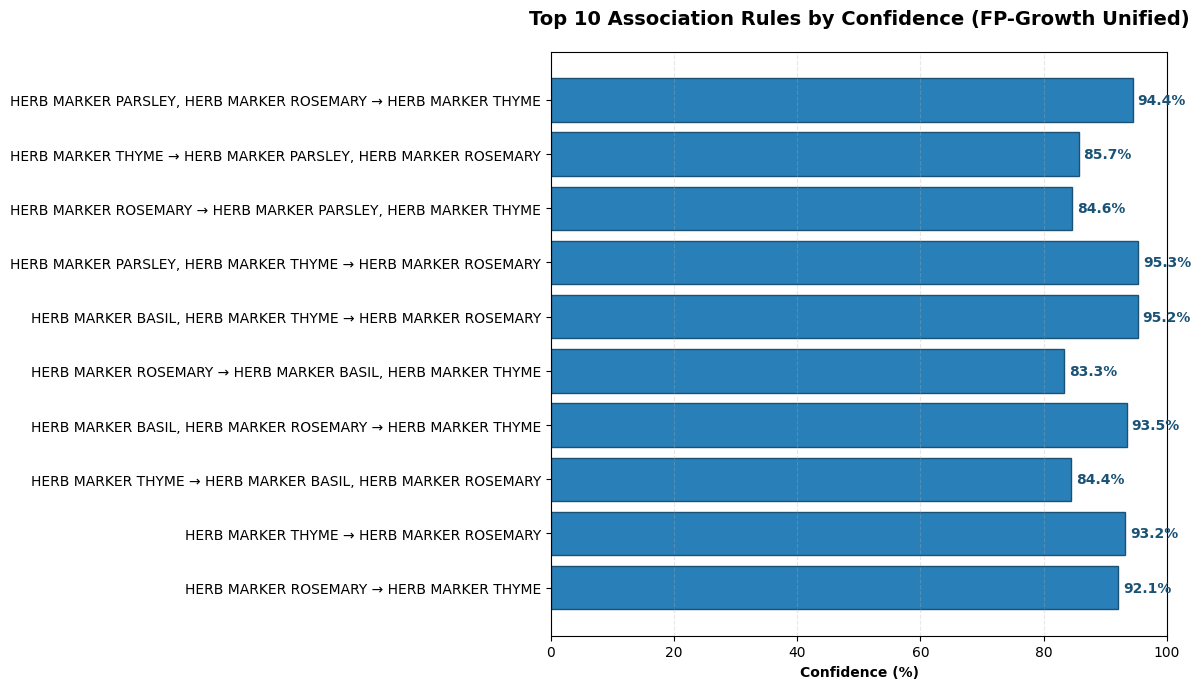

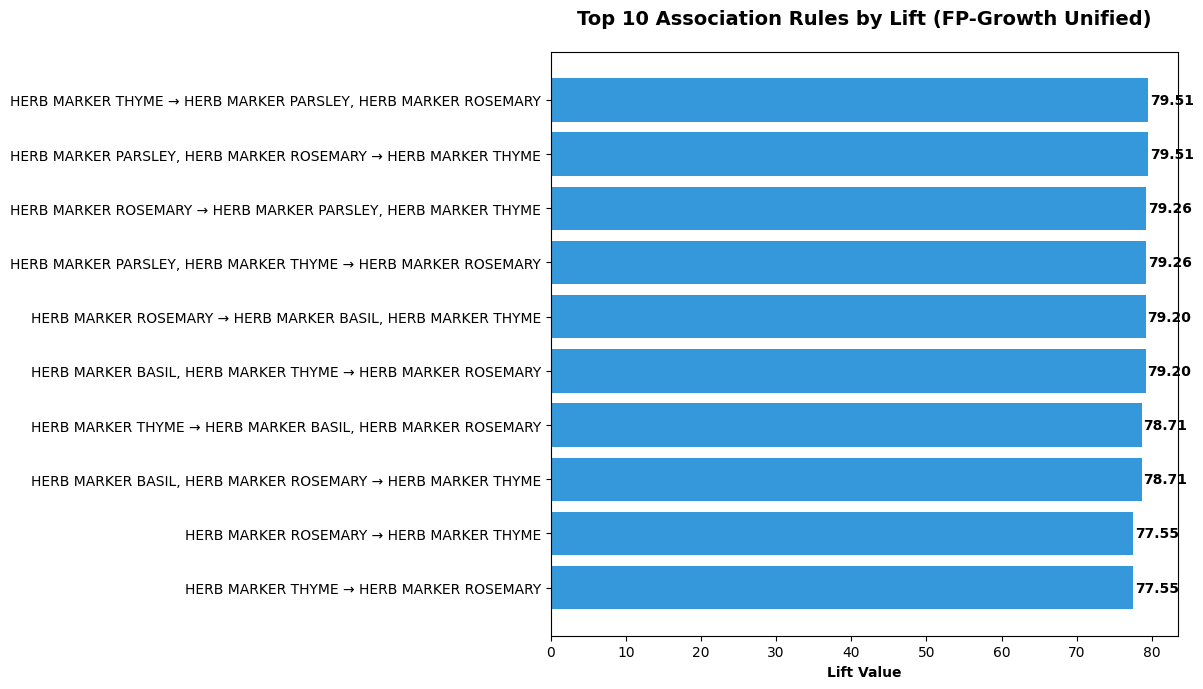

In [8]:
import matplotlib.pyplot as plt

top_rules = rules_fp.head(10).copy()

top_rules['rule'] = top_rules.apply(
    lambda x: f"{', '.join(list(x['antecedents']))} → {', '.join(list(x['consequents']))}",
    axis=1
)

top_rules['confidence_pct'] = top_rules['confidence'] * 100

plt.figure(figsize=(12, 7))

bars = plt.barh(
    range(len(top_rules)),
    top_rules['confidence_pct'],
    color='#2980b9',  
    edgecolor='#1a5276'
)

plt.yticks(
    range(len(top_rules)),
    top_rules['rule'],
    fontsize=10
)

plt.xlabel("Confidence (%)", fontweight='bold')
plt.title("Top 10 Association Rules by Confidence (FP-Growth Unified)", fontsize=14, fontweight='bold', pad=20)

plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.3)

for i, bar in enumerate(bars):
    plt.text(
        bar.get_width() + 0.8, 
        bar.get_y() + bar.get_height()/2,
        f"{top_rules['confidence_pct'].iloc[i]:.1f}%",
        va='center',
        fontweight='bold',
        color='#1a5276'
    )

plt.tight_layout()
plt.show()

top_rules_lift = rules_fp.sort_values('lift', ascending=False).head(10).copy()
top_rules_lift['rule'] = top_rules_lift.apply(
    lambda x: f"{', '.join(list(x['antecedents']))} → {', '.join(list(x['consequents']))}",
    axis=1
)

plt.figure(figsize=(12, 7))
bars_lift = plt.barh(range(len(top_rules_lift)), top_rules_lift['lift'], color='#3498db')

plt.yticks(range(len(top_rules_lift)), top_rules_lift['rule'])
plt.xlabel("Lift Value", fontweight='bold')
plt.title("Top 10 Association Rules by Lift (FP-Growth Unified)", fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

for i, bar in enumerate(bars_lift):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{top_rules_lift['lift'].iloc[i]:.2f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

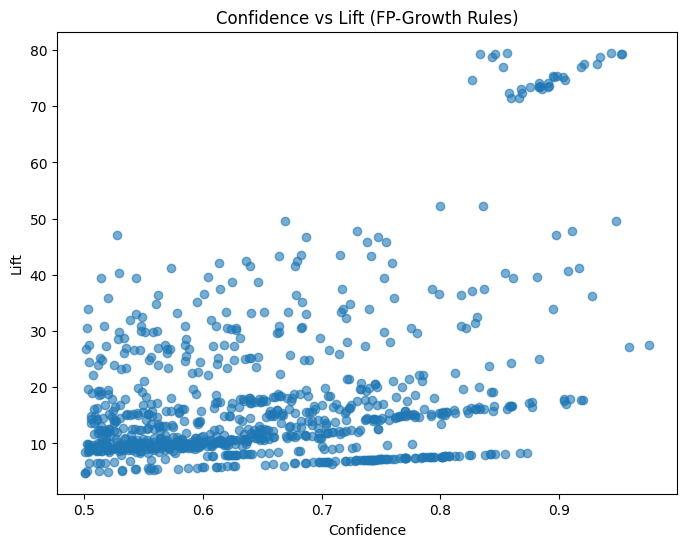

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(rules['confidence'], rules['lift'], alpha=0.6)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift (FP-Growth Rules)")

plt.show()

# Logistic Regression


Creating RFM Table...
RFM Table Shape: (4338, 3)
HighValue Class Distribution (%):
HighValue
0    60.00461
1    39.99539
Name: proportion, dtype: float64

IMPROVED Logistic Regression Performance
Accuracy          : 93.55%
Precision         : 96.00%
Recall            : 87.52%
F1-Score          : 91.57%
AUC Score         : 98.85%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       781
           1       0.96      0.88      0.92       521

    accuracy                           0.94      1302
   macro avg       0.94      0.93      0.93      1302
weighted avg       0.94      0.94      0.93      1302


Confusion Matrix:


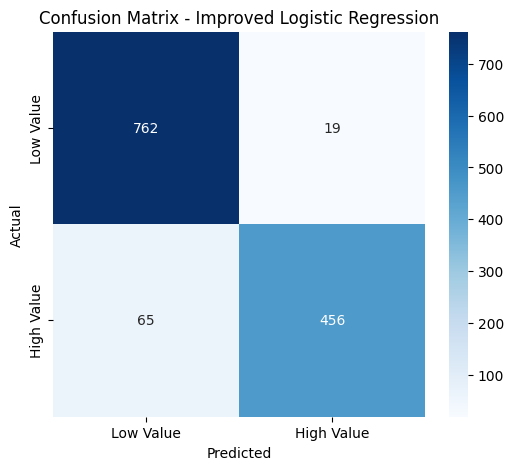

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating RFM Table...")

rfm = sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (sales['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})

rfm = rfm[rfm.index.notna()].copy()
rfm = rfm.fillna(0)

print(f"RFM Table Shape: {rfm.shape}")

rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency'].replace(0, 1)

threshold = rfm['Monetary'].quantile(0.6)
rfm['HighValue'] = (rfm['Monetary'] > threshold).astype(int)

X = rfm[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']]
y = rfm['HighValue']

print(f"HighValue Class Distribution (%):\n{y.value_counts(normalize=True) * 100}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    C=0.1,
    solver='liblinear'
)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("\nIMPROVED Logistic Regression Performance")
print("=" * 75)

print(f"Accuracy          : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision         : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall            : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1-Score          : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"AUC Score         : {roc_auc_score(y_test, y_pred_proba) * 100:.2f}%")

print("\n" + "=" * 75)
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\n" + "=" * 75)
print("Confusion Matrix:")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Value', 'High Value'],
    yticklabels=['Low Value', 'High Value']
)

plt.title('Confusion Matrix - Improved Logistic Regression')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show

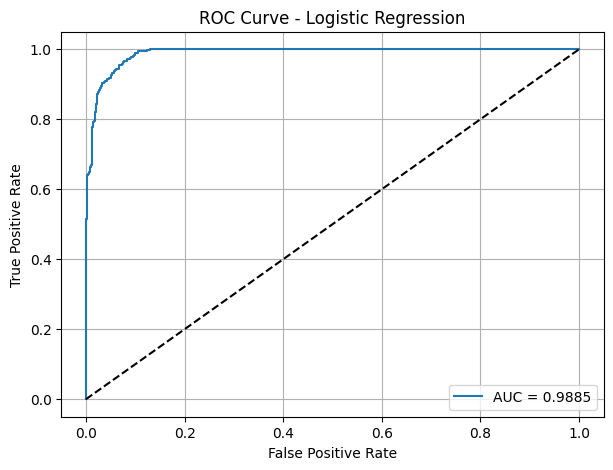

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.4f}')
plt.plot([0,1], [0,1], 'k--')

plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

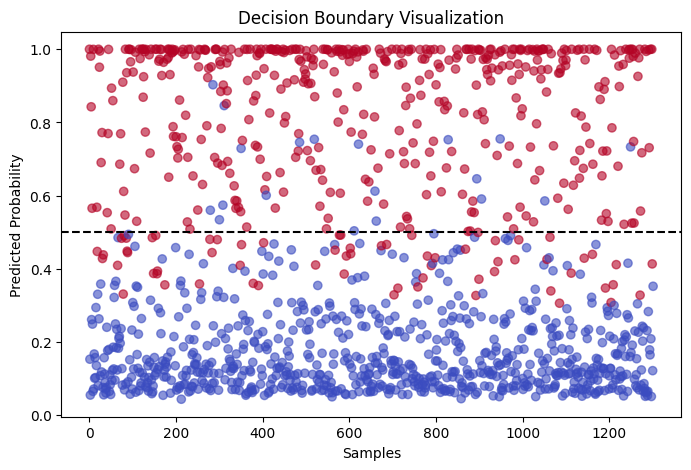

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(y_pred_proba)),
            y_pred_proba,
            c=y_test,
            cmap='coolwarm',
            alpha=0.6)

plt.axhline(0.5, color='black', linestyle='--')

plt.title('Decision Boundary Visualization')
plt.xlabel('Samples')
plt.ylabel('Predicted Probability')
plt.show()

# CUSTOMER SEGMENTATION USING K-MEANS

<>:244: DeprecationWarning: invalid escape sequence '\C'
<>:244: DeprecationWarning: invalid escape sequence '\C'
C:\Users\Malak Eissa\AppData\Local\Temp\ipykernel_24344\65852155.py:244: DeprecationWarning: invalid escape sequence '\C'
  print("\CLUSTERING SCORES")


CREATING ADVANCED RFM FEATURES
Initial Shape: (4338, 5)
Shape After Outlier Removal: (2504, 5)

Creating Strong Features...

Applying Log Transformation...

Scaling Features...

Applying PCA...
Explained Variance Ratio: 90.73%

Finding Optimal Number of Clusters...


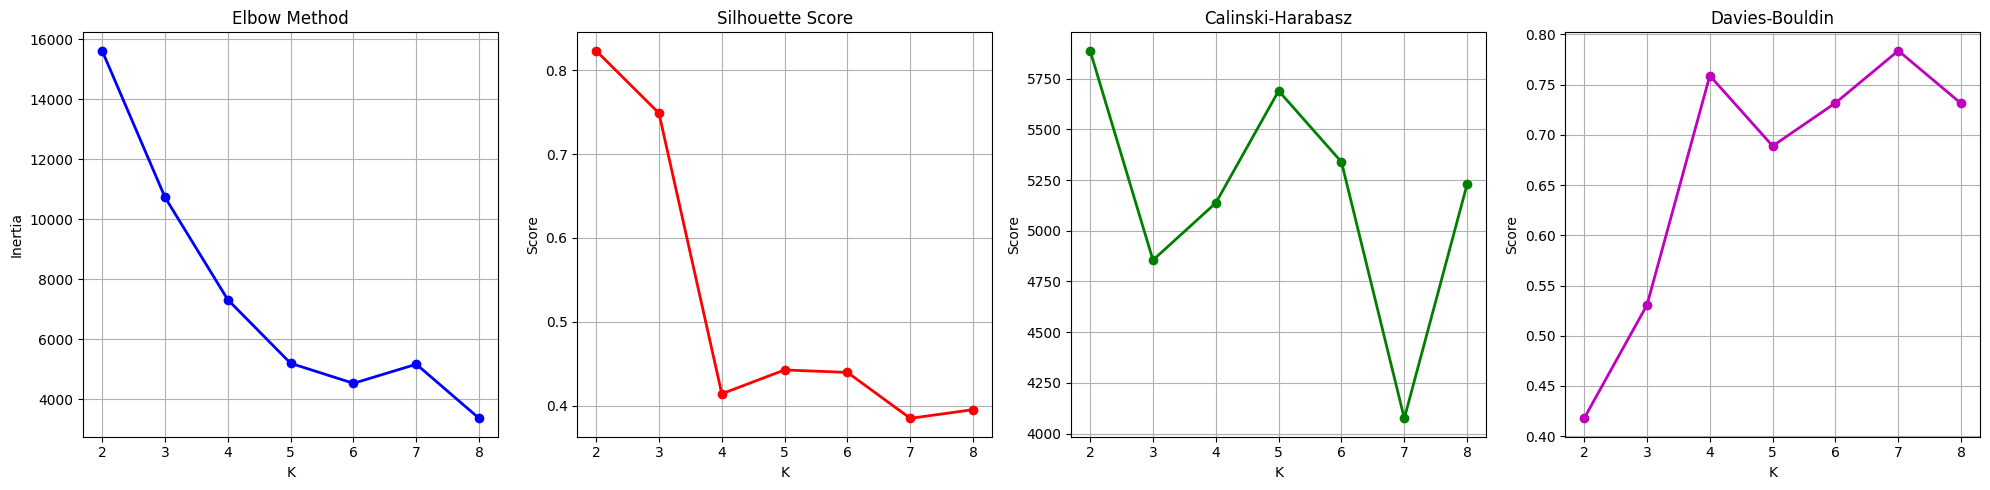


BEST K FOUND = 2

ULTRA-STRONG K-MEANS RESULTS - K = 2

Cluster Sizes:
Cluster
0    2348
1     156
Name: count, dtype: int64

Cluster Profiles:
         Recency  Frequency  Monetary  AvgOrderValue  MaxOrderValue  \
Cluster                                                               
0           4.75       1.35      6.56           2.92           4.12   
1           1.31       1.88      7.32           2.95           4.32   

         PurchaseRate  MonetaryPerVisit  ValueScore  
Cluster                                              
0                0.05              5.21        7.55  
1                0.94              5.45        9.02  
\CLUSTERING SCORES
--------------------------------------------------
Silhouette Score       : 0.8231
Calinski-Harabasz     : 5888.11
 Davies-Bouldin Score  : 0.4177

MODEL QUALITY
 EXCELLENT clustering quality


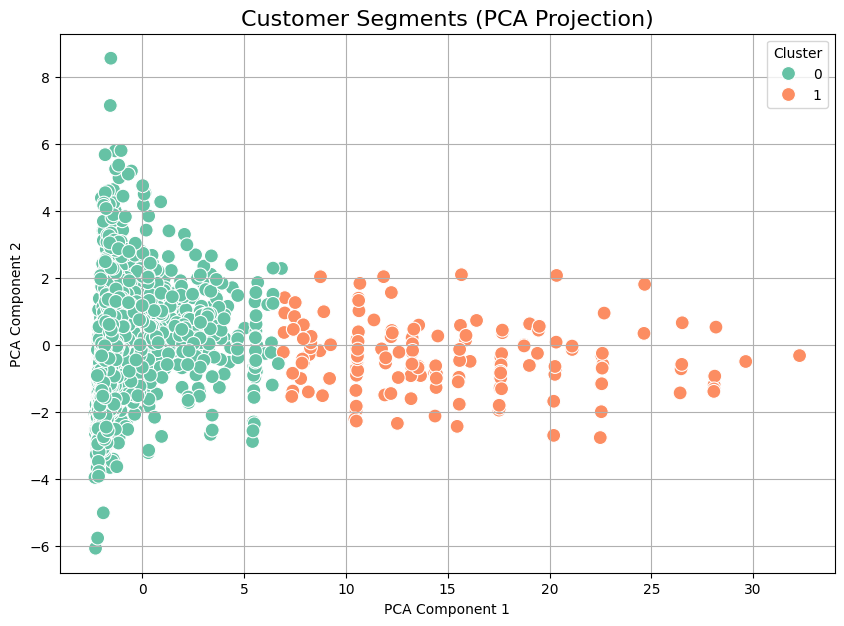


CUSTOMER SEGMENT INTERPRETATION

Cluster 0
Lost / Inactive Customers

Cluster 1
VIP / High-Value Customers

 Customer segments saved successfully.
Ultra-strong clustering pipeline completed.


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

print("="*80)
print("CREATING ADVANCED RFM FEATURES")
print("="*80)

snapshot_date = sales['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': ['sum', 'mean', 'max']
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary',
    'AvgOrderValue',
    'MaxOrderValue'
]

rfm = rfm[rfm.index.notna()].copy()

rfm = rfm[
    (rfm['Monetary'] > 0) &
    (rfm['Frequency'] > 0)
]

print(f"Initial Shape: {rfm.shape}")



for col in ['Recency', 'Frequency', 'Monetary']:

    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    rfm = rfm[
        (rfm[col] >= lower) &
        (rfm[col] <= upper)
    ]

print(f"Shape After Outlier Removal: {rfm.shape}")


print("\nCreating Strong Features...")

rfm['PurchaseRate'] = (
    rfm['Frequency'] / (rfm['Recency'] + 1)
)

rfm['MonetaryPerVisit'] = (
    rfm['Monetary'] / (rfm['Frequency'] + 1)
)

rfm['ValueScore'] = (
    rfm['Monetary'] * rfm['Frequency']
)



print("\nApplying Log Transformation...")

for col in rfm.columns:
    rfm[col] = np.log1p(rfm[col])



features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AvgOrderValue',
    'MaxOrderValue',
    'PurchaseRate',
    'MonetaryPerVisit',
    'ValueScore'
]

X = rfm[features]


print("\nScaling Features...")

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)



print("\nApplying PCA...")

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.2%}")


print("\nFinding Optimal Number of Clusters...")

silhouette_scores = []
calinski_scores = []
db_scores = []
inertia = []

K_range = range(2, 9)

for k in K_range:

    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=256,
        n_init=20,
        max_iter=500
    )

    labels = model.fit_predict(X_pca)

    silhouette_scores.append(
        silhouette_score(X_pca, labels)
    )

    calinski_scores.append(
        calinski_harabasz_score(X_pca, labels)
    )

    db_scores.append(
        davies_bouldin_score(X_pca, labels)
    )

    inertia.append(model.inertia_)


plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.plot(K_range, inertia, 'bo-', linewidth=2)
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1, 4, 2)
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2)
plt.title('Silhouette Score')
plt.xlabel('K')
plt.ylabel('Score')
plt.grid(True)

plt.subplot(1, 4, 3)
plt.plot(K_range, calinski_scores, 'go-', linewidth=2)
plt.title('Calinski-Harabasz')
plt.xlabel('K')
plt.ylabel('Score')
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(K_range, db_scores, 'mo-', linewidth=2)
plt.title('Davies-Bouldin')
plt.xlabel('K')
plt.ylabel('Score')
plt.grid(True)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]

print("\n" + "="*80)
print(f"BEST K FOUND = {optimal_k}")
print("="*80)


final_model = MiniBatchKMeans(
    n_clusters=optimal_k,
    random_state=42,
    batch_size=256,
    n_init=20,
    max_iter=500
)

rfm['Cluster'] = final_model.fit_predict(X_pca)


final_silhouette = silhouette_score(
    X_pca,
    rfm['Cluster']
)

final_calinski = calinski_harabasz_score(
    X_pca,
    rfm['Cluster']
)

final_db = davies_bouldin_score(
    X_pca,
    rfm['Cluster']
)

print("\n" + "="*80)
print(f"ULTRA-STRONG K-MEANS RESULTS - K = {optimal_k}")
print("="*80)

print("\nCluster Sizes:")
print(
    rfm['Cluster']
    .value_counts()
    .sort_index()
)

print("\nCluster Profiles:")

cluster_profile = (
    rfm.groupby('Cluster')[features]
    .mean()
    .round(2)
)

print(cluster_profile)

print("\CLUSTERING SCORES")
print("-"*50)

print(f"Silhouette Score       : {final_silhouette:.4f}")
print(f"Calinski-Harabasz     : {final_calinski:.2f}")
print(f" Davies-Bouldin Score  : {final_db:.4f}")


print("\n" + "="*80)
print("MODEL QUALITY")
print("="*80)

if final_silhouette >= 0.70:
    print(" EXCELLENT clustering quality")

elif final_silhouette >= 0.50:
    print("STRONG clustering quality")

elif final_silhouette >= 0.35:
    print(" MODERATE clustering quality")

else:
    print(" WEAK clustering quality")

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=rfm['Cluster'],
    palette='Set2',
    s=100
)

plt.title(
    'Customer Segments (PCA Projection)',
    fontsize=16
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.grid(True)
plt.show()

print("\n" + "="*80)
print("CUSTOMER SEGMENT INTERPRETATION")
print("="*80)

for cluster in sorted(rfm['Cluster'].unique()):

    segment = cluster_profile.loc[cluster]

    print(f"\nCluster {cluster}")

    if (
        segment['Monetary'] >
        cluster_profile['Monetary'].mean()
    ) and (
        segment['Frequency'] >
        cluster_profile['Frequency'].mean()
    ):

        print("VIP / High-Value Customers")

    elif (
        segment['Recency'] >
        cluster_profile['Recency'].mean()
    ):

        print("Lost / Inactive Customers")

    elif (
        segment['Frequency'] <
        cluster_profile['Frequency'].mean()
    ):

        print(" Occasional Customers")

    else:
        print(" Loyal Customers")


rfm.to_csv('customer_segments.csv')

print("\n Customer segments saved successfully.")
print("Ultra-strong clustering pipeline completed.")

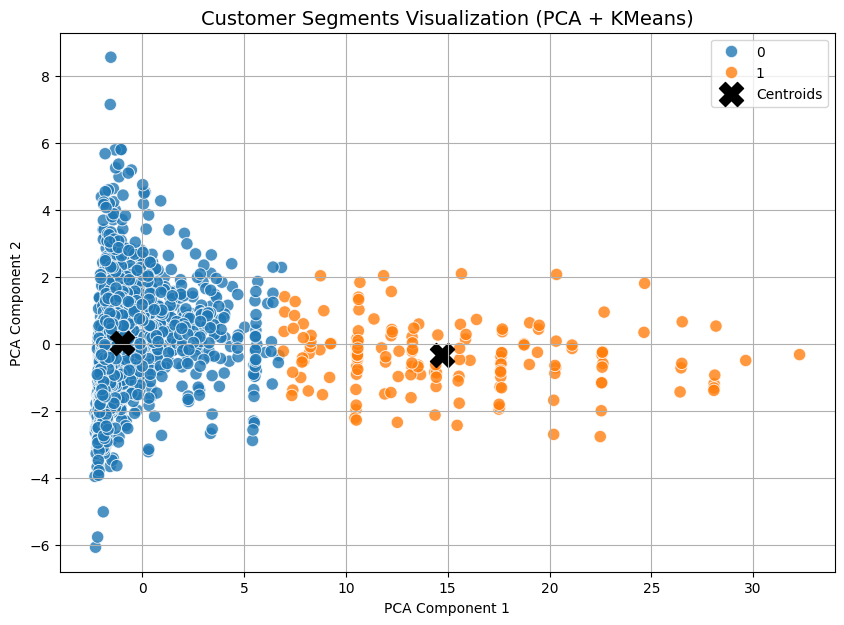

In [8]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=rfm['Cluster'],
    palette='tab10',
    s=80,
    alpha=0.8
)

# Plot cluster centers
centers = final_model.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='black',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments Visualization (PCA + KMeans)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

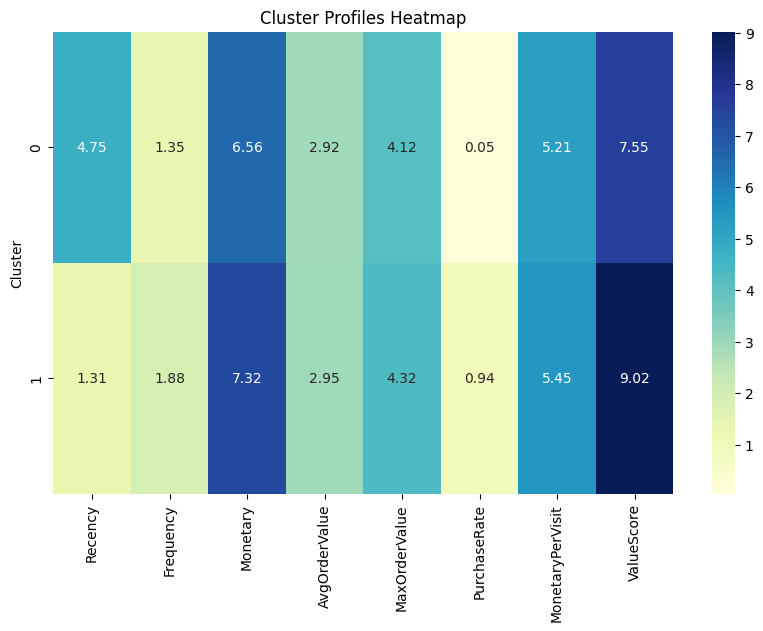

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title('Cluster Profiles Heatmap')
plt.show()